In [119]:
from keras.utils import to_categorical
from keras import layers
from keras import models
from keras import optimizers
import matplotlib.pyplot as plt
import os

In [3]:
import os, shutil

base_dir = "./cats_and_dogs_small"
path = "../kagglecatsanddogs_3367a"
original_dataset_dir = os.path.join(path, "PetImages")

cat_src_dir = os.path.join(original_dataset_dir, 'Cat')
dog_src_dir = os.path.join(original_dataset_dir, 'Dog')
print(f"Cat dir exists: {os.path.exists(cat_src_dir)}")
print(f"Dog dir exists: {os.path.exists(dog_src_dir)}")

if os.path.exists(base_dir):
    print("ลบ folder เก่าและสร้างใหม่")
    shutil.rmtree(base_dir)

os.makedirs(base_dir, exist_ok=True)

train_dir = os.path.join(base_dir, 'train')
os.makedirs(train_dir, exist_ok=True)

test_dir = os.path.join(base_dir, 'test')
os.makedirs(test_dir, exist_ok=True)

validation_dir = os.path.join(base_dir, 'validation')
os.makedirs(validation_dir, exist_ok=True)

folders = [
    os.path.join(train_dir, 'cats'), os.path.join(train_dir, 'dogs'),
    os.path.join(validation_dir, 'cats'), os.path.join(validation_dir, 'dogs'),
    os.path.join(test_dir, 'cats'), os.path.join(test_dir, 'dogs')
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("สร้างโครงสร้าง Directory ทั้งหมดใน week9 เรียบร้อยแล้ว")

Cat dir exists: True
Dog dir exists: True
ลบ folder เก่าและสร้างใหม่
สร้างโครงสร้าง Directory ทั้งหมดใน week9 เรียบร้อยแล้ว


In [4]:
cat_files = [f for f in os.listdir(cat_src_dir)]
dog_files = [f for f in os.listdir(dog_src_dir)]

train_cats = cat_files[:1000]
train_dogs = dog_files[:1000]

val_cats = cat_files[1000:1500]
val_dogs = dog_files[1000:1500]

test_cats = cat_files[1500:2000]
test_dogs = dog_files[1500:2000]

In [5]:
def copy_files(file_list, src_dir, dst_dir):
    for fname in file_list:
        src = os.path.join(src_dir, fname)
        dst = os.path.join(dst_dir, fname)
        shutil.copyfile(src, dst)

In [6]:
copy_files(train_cats, cat_src_dir, os.path.join(base_dir, "train", "cats"))
copy_files(val_cats, cat_src_dir, os.path.join(base_dir, "validation", "cats"))
copy_files(test_cats, cat_src_dir, os.path.join(base_dir, "test", "cats"))
copy_files(train_dogs, dog_src_dir, os.path.join(base_dir, "train", "dogs"))
copy_files(val_dogs, dog_src_dir, os.path.join(base_dir, "validation", "dogs"))
copy_files(test_dogs, dog_src_dir, os.path.join(base_dir, "test", "dogs"))

print("Dataset ready at:", base_dir)
print(len(train_cats), len(val_cats), len(test_cats))
print(len(train_dogs), len(val_dogs), len(test_dogs))

Dataset ready at: ./cats_and_dogs_small
1000 500 500
1000 500 500


In [7]:
for name in ["train", "validation", "test"]:
    print(os.path.join(base_dir, name, "cats"))
    print(len(os.listdir(os.path.join(base_dir, name, "cats"))))
    print(os.path.join(base_dir, name, "dogs"))
    print(len(os.listdir(os.path.join(base_dir, name, "dogs"))))

./cats_and_dogs_small/train/cats
1000
./cats_and_dogs_small/train/dogs
1000
./cats_and_dogs_small/validation/cats
500
./cats_and_dogs_small/validation/dogs
500
./cats_and_dogs_small/test/cats
500
./cats_and_dogs_small/test/dogs
500


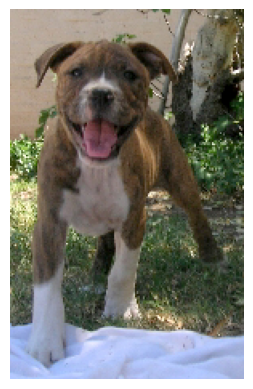

Image size (width, height): (146, 231)
Image shape (height, width, channels


In [8]:
import matplotlib.pyplot as plt
from PIL import Image
img_path = os.path.join(dog_src_dir, dog_files[500])
img = Image.open(img_path)
plt.imshow(img)
plt.axis('off')
plt.show()
print("Image size (width, height):", img.size)
import numpy as np
print("Image shape (height, width, channels")

In [9]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

/Users/ponlawatchangto/Documents/Mylearning/4312/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=1e-4),
    metrics=['accuracy']
)

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255) # ตั้งค่าไว้ก่อน ยังไม่

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory( train_dir, target_size=(150, 150), batch_size=20, class_mode='binary')

validation_generator = test_datagen.flow_from_directory( validation_dir, target_size=(150, 150), batch_size=20, class_mode='binary')

Found 1998 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [12]:
for data_batch, labels_batch in train_generator:
    print('data batch shape:', data_batch.shape)
    print('labels batch shape:', labels_batch.shape)
    break   

data batch shape: (20, 150, 150, 3)
labels batch shape: (20,)


In [13]:
# history = model.fit(train_generator,steps_per_epoch=100,epochs=30,validation_data=validation_generator,validation_steps=50)

In [14]:
model.save('cats_and_dogs_small_1.h5')

In [16]:
# import matplotlib.pyplot as plt

# acc = history.history['accuracy']

# val_acc = history.history['val_accuracy']

# loss = history.history['loss']

# val_loss = history.history['val_loss']

# epochs = range(1, len(acc) + 1)

# plt.plot(epochs, acc, 'bo', label='Training acc')

# plt.plot(epochs, val_acc, 'b', label='Validation acc')

# plt.title('Training and validation accuracy')

# plt.legend()

# plt.figure()
# plt.plot(epochs, loss, 'bo', label='Training loss')

# plt.plot(epochs, val_loss, 'b', label='Validation loss')

# plt.title('Training and validation loss')

# plt.legend()

# plt.show()

In [120]:
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
    )

In [121]:
from keras.preprocessing import image

train_cats_dir = os.path.join("./cats_and_dogs_small/","train","cats")
train_dogs_dir = os.path.join("./cats_and_dogs_small/","train","dogs")

fnames = [os.path.join(train_cats_dir, fname) for fname in
os.listdir(train_cats_dir)]

img_path = fnames[3]

img = image.load_img(img_path, target_size=(150, 150))

x = image.img_to_array(img)

x = x.reshape((1,) + x.shape)

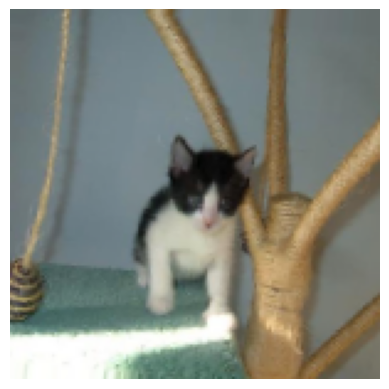

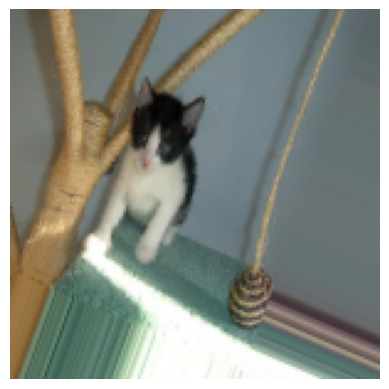

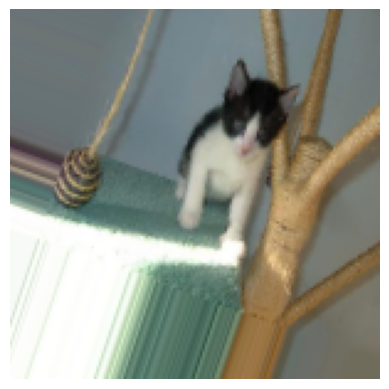

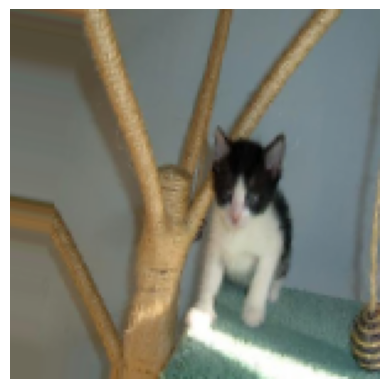

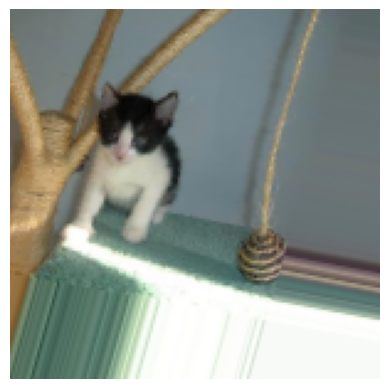

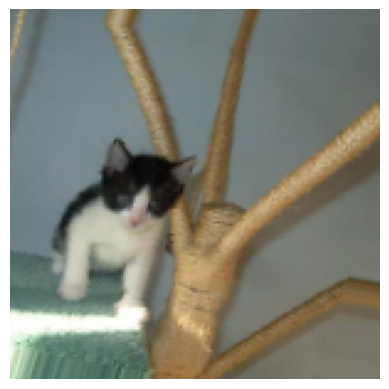

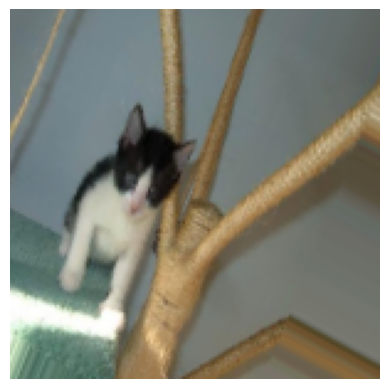

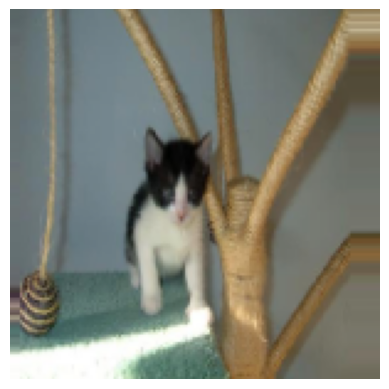

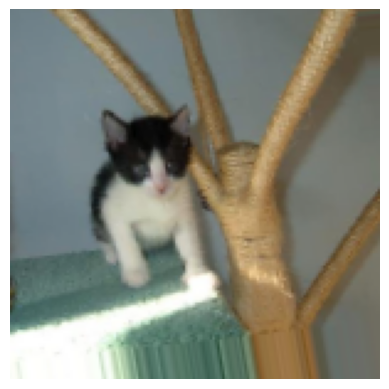

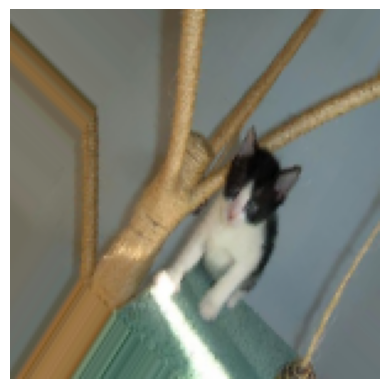

In [64]:
i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    plt.axis('off')
    imgplot = plt.imshow(image.array_to_img(batch[0])) 
    i += 1
    if i % 10 == 0:  
        break

plt.show()

In [ ]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150,
150, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy',
optimizer=optimizers.RMSprop(learning_rate=1e-4),
metrics=['accuracy'])

/Users/ponlawatchangto/Documents/Mylearning/4312/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [123]:
train_datagen = ImageDataGenerator(

rescale=1./255,
rotation_range=40,
width_shift_range=0.2,
height_shift_range=0.2,
shear_range=0.2,
zoom_range=0.2,
horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
train_dir,
target_size=(150, 150),
batch_size=32,
class_mode='binary')

Found 1998 images belonging to 2 classes.


In [67]:
validation_generator = test_datagen.flow_from_directory(
validation_dir,
target_size=(150, 150),
batch_size=32,
class_mode='binary')

history = model.fit(
train_generator,
steps_per_epoch=100,
epochs=100,
validation_data=validation_generator,
validation_steps=50)

model.save('cats_and_dogs_small_2.h5')

Found 1000 images belonging to 2 classes.
Epoch 1/100
 13/100 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - accuracy: 0.4396 - loss: 0.6943

/Users/ponlawatchangto/Documents/Mylearning/4312/.venv/lib/python3.13/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


 63/100 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.4692 - loss: 0.6948

/Users/ponlawatchangto/Documents/Mylearning/4312/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.4950 - loss: 0.6945 - val_accuracy: 0.5000 - val_loss: 0.6909
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.5105 - loss: 0.6911 - val_accuracy: 0.5540 - val_loss: 0.6871
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - accuracy: 0.5495 - loss: 0.6864 - val_accuracy: 0.5550 - val_loss: 0.6806
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.5631 - loss: 0.6810 - val_accuracy: 0.5680 - val_loss: 0.6742
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.5736 - loss: 0.6730 - val_accuracy: 0.5880 - val_loss: 0.6708
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.5976 - loss: 0.6644 - val_accuracy: 0.5360 - val_loss: 0.7053
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - accuracy: 0.5886 - loss: 0.6634 - val_accuracy: 0.5090 - val_loss: 0.7581
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.5986 - loss: 0.6621 - val_accuracy

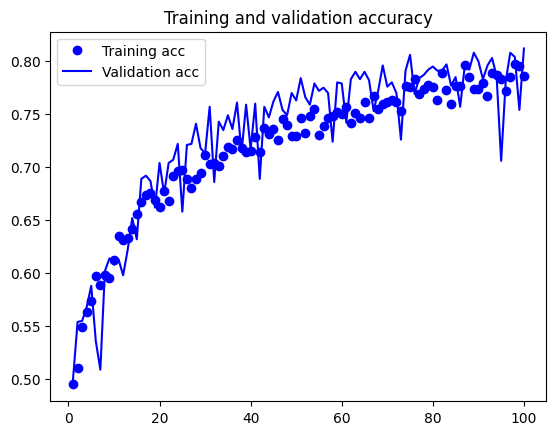

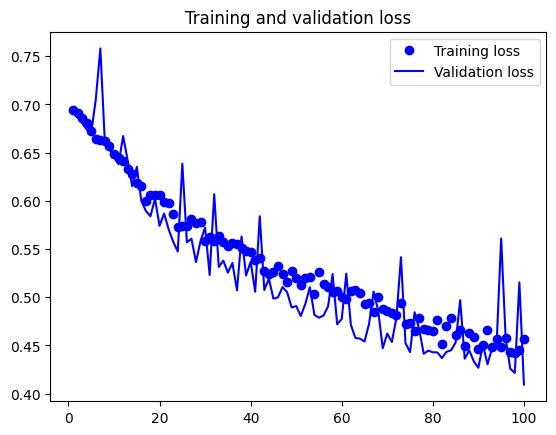

In [68]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [124]:
from keras.applications import VGG16

conv_base = VGG16 (
    weights = 'imagenet' , 
    include_top = False ,
    input_shape = (150,150,3)
)
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [125]:
base_dir = './cats_and_dogs_small'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

datagen = ImageDataGenerator(rescale=1./255)
batch_size = 20

In [126]:
def extract_features(directory, sample_count):
    features = np.zeros(shape=(sample_count, 4, 4, 512))
    labels = np.zeros(shape=(sample_count))
    generator = datagen.flow_from_directory(
        directory,
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')
    i = 0
    for inputs_batch, labels_batch in generator:
        features_batch = conv_base.predict(inputs_batch)
        
        current_batch_size = len(features_batch)
        features[i * batch_size : i * batch_size + current_batch_size] = features_batch
        labels[i * batch_size : i * batch_size + current_batch_size] = labels_batch
        
        i += 1
        if i * batch_size >= sample_count:
            break
    return features, labels

In [127]:
train_features, train_labels = extract_features(train_dir, 2000)
validation_features, validation_labels = extract_features(validation_dir, 1000)
test_features, test_labels = extract_features(test_dir, 1000)

Found 1998 images belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step
1/1 ━━━━━━━━━━━━━━━━━━

/Users/ponlawatchangto/Documents/Mylearning/4312/.venv/lib/python3.13/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step
Found 1000 images belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step
1/1 ━━━━━━━━━━━━━━━━━━

In [128]:
train_features = np.reshape(train_features, (2000, 4 * 4 * 512))

validation_features = np.reshape(validation_features, (1000, 4 * 4 * 512))

test_features = np.reshape(test_features, (1000, 4 * 4 * 512))

In [129]:
model = models.Sequential()
model.add(layers.Dense(256, activation='relu', input_dim = 4 * 4 * 512))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer=optimizers.RMSprop(learning_rate=2e-5),
loss='binary_crossentropy',
metrics=['acc'])

history = model.fit(train_features, train_labels,
epochs=30,
batch_size=20,
validation_data=(validation_features, validation_labels))

Epoch 1/30


/Users/ponlawatchangto/Documents/Mylearning/4312/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.6780 - loss: 0.5910 - val_acc: 0.8380 - val_loss: 0.4472
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8175 - loss: 0.4201 - val_acc: 0.8260 - val_loss: 0.3885
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8380 - loss: 0.3661 - val_acc: 0.8600 - val_loss: 0.3411
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8570 - loss: 0.3308 - val_acc: 0.8650 - val_loss: 0.3166
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8780 - loss: 0.2990 - val_acc: 0.8720 - val_loss: 0.3011
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8865 - loss: 0.2691 - val_acc: 0.8880 - val_loss: 0.2854
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9005 - loss: 0.2539 - val_acc: 0.8940 - val_loss: 0.2767
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9060 - loss: 0.2379 - val_acc: 0.8940 - val_loss: 0.2694
Epoch 9/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9080 -

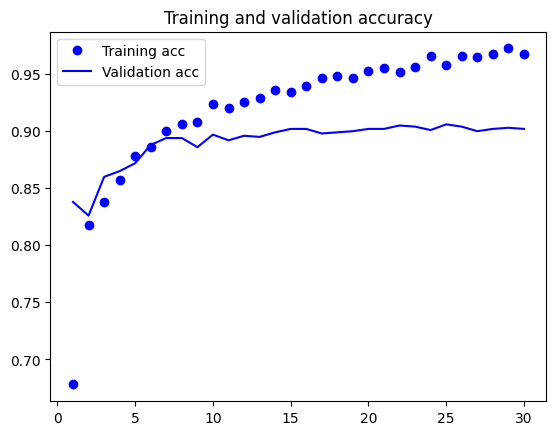

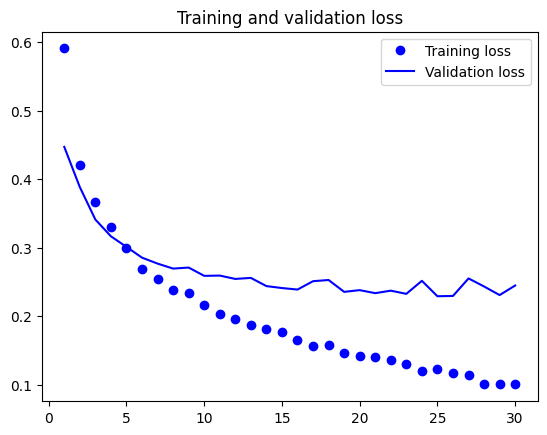

In [130]:
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [131]:
model = models.Sequential()
model.add(conv_base)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 16,812,353 (64.13 MB)

 Non-trainable params: 0 (0.00 B)

In [132]:
print('This is the number of trainable weights ', 'before freezing the conv base:', len(model.trainable_weights))

This is the number of trainable weights  before freezing the conv base: 30


In [133]:
conv_base.trainable = False

In [134]:
print('This is the number of trainable weights ','after freezing the conv base:', len(model.trainable_weights))

This is the number of trainable weights  after freezing the conv base: 4


In [135]:
ImageDataGenerator(
rotation_range=40,
width_shift_range=0.2,
zoom_range=0.2,
horizontal_flip=True
)

In [136]:
train_datagen = ImageDataGenerator(
rescale=1./255,
rotation_range=40,
width_shift_range=0.2,
height_shift_range=0.2,
shear_range=0.2,
zoom_range=0.2,
horizontal_flip=True,
fill_mode='nearest')

test_datagen = ImageDataGenerator(rescale=1./255)

In [137]:
train_generator = train_datagen.flow_from_directory(
train_dir,
target_size=(150, 150),
batch_size=20,
class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
validation_dir,
target_size=(150, 150),
batch_size=20,
class_mode='binary')

model.compile(loss='binary_crossentropy',
optimizer=optimizers.RMSprop(learning_rate=2e-5),
metrics=['acc'])

Found 1998 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [139]:
history = model.fit(
train_generator,
steps_per_epoch=100,
epochs=30,
validation_data=validation_generator,
validation_steps=50)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 56s 557ms/step - acc: 0.8243 - loss: 0.3935 - val_acc: 0.8760 - val_loss: 0.3066
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 57s 570ms/step - acc: 0.8428 - loss: 0.3715 - val_acc: 0.8870 - val_loss: 0.2895
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 56s 566ms/step - acc: 0.8388 - loss: 0.3637 - val_acc: 0.8820 - val_loss: 0.2825
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 56s 564ms/step - acc: 0.8504 - loss: 0.3395 - val_acc: 0.8830 - val_loss: 0.2743
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 56s 566ms/step - acc: 0.8519 - loss: 0.3386 - val_acc: 0.8940 - val_loss: 0.2652
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 57s 568ms/step - acc: 0.8483 - loss: 0.3511 - val_acc: 0.8920 - val_loss: 0.2641
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 57s 567ms/step - acc: 0.8393 - loss: 0.3426 - val_acc: 0.8940 - val_loss: 0.2576
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 57s 570ms/step - acc: 0.8649 - loss: 0.3251 - val_acc: 0.8940 - val_loss: 0.2523
Epoch 9/30
100/100 ━━━━━━━━━━━━━

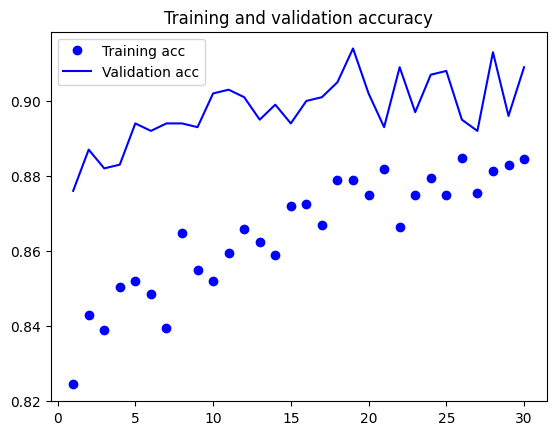

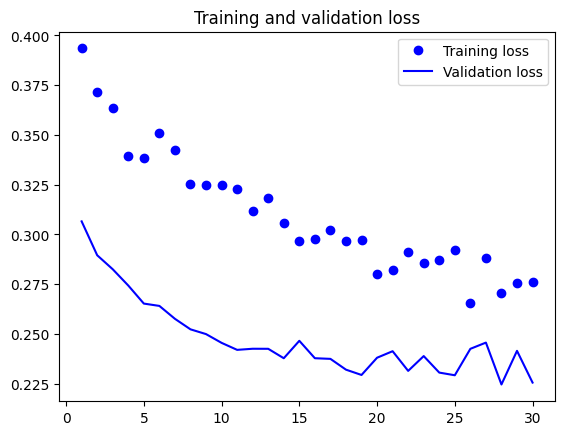

In [140]:
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()